<a href="https://colab.research.google.com/github/Salome-06/Estadistica/blob/main/Ejer_sustentacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATOS ORIGINALES:
            Superficie  Frecuencia Cardíaca Máxima
0      Pista de Tartán                         172
1      Pista de Tartán                         168
2      Pista de Tartán                         175
3      Pista de Tartán                         170
4      Pista de Tartán                         178
5      Pista de Tartán                         165
6      Pista de Tartán                         173
7      Pista de Tartán                         176
8       Asfalto Urbano                         180
9       Asfalto Urbano                         185
10      Asfalto Urbano                         178
11      Asfalto Urbano                         183
12      Asfalto Urbano                         188
13      Asfalto Urbano                         176
14      Asfalto Urbano                         182
15      Asfalto Urbano                         186
16  Sendero de Montaña                         190
17  Sendero de Montaña                         195
18  Sendero d

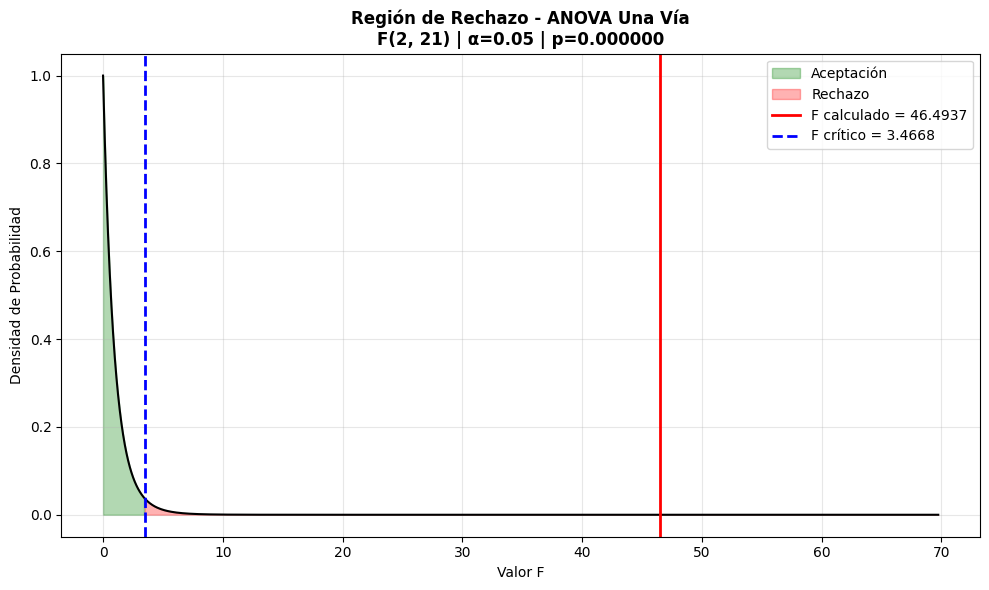

ANÁLISIS COMPLETO FINALIZADO


In [2]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ============================================================================
# DATOS DEL PROBLEMA
# ============================================================================

data = {
    'Superficie': ['Pista de Tartán'] * 8 + ['Asfalto Urbano'] * 8 + ['Sendero de Montaña'] * 8,
    'Frecuencia Cardíaca Máxima': [172, 168, 175, 170, 178, 165, 173, 176, 180, 185, 178, 183, 188, 176, 182, 186, 190, 195, 188, 193, 198, 186, 192, 196]
}

df = pd.DataFrame(data)
superficies = df['Superficie'].unique()

# ============================================================================
# CÁLCULOS PRELIMINARES
# ============================================================================

datos = [df[df['Superficie'] == i]['Frecuencia Cardíaca Máxima'].values for i in superficies]
n_grupos = len(superficies)
n_obs = [len(g) for g in datos]
n_total = sum(n_obs)

media_global = df['Frecuencia Cardíaca Máxima'].mean()
medias_superficie = df.groupby('Superficie')['Frecuencia Cardíaca Máxima'].mean().values

print("DATOS ORIGINALES:")
print(df)
print("\nMedias por Superficie:")
for i, superficie in enumerate(superficies):
    print(f"  {superficie}: {medias_superficie[i]:.4f}")
print(f"Media Global: {media_global:.4f}\n")

# ============================================================================
# ANOVA DE UNA VÍA MANUAL
# ============================================================================

SCT = np.sum((df['Frecuencia Cardíaca Máxima'] - media_global)**2)
SCB = sum([n_obs[i]*(medias_superficie[i] - media_global)**2 for i in range(n_grupos)])
SCE = SCT - SCB

gl_b = n_grupos - 1
gl_e = n_total - n_grupos
gl_t = n_total - 1

CMb = SCB / gl_b
CMe = SCE / gl_e

F = CMb / CMe
p_value = 1 - stats.f.cdf(F, gl_b, gl_e)
F_crit = stats.f.ppf(0.95, gl_b, gl_e)

# ============================================================================
# TABLA ANOVA
# ============================================================================

print("TABLA ANOVA DE UNA VÍA")
print("="*80)
print(f"{'Fuente de Variación':<20} {'SC':>12} {'gl':>6} {'CM':>12} {'F':>12} {'Valor-p':>12}")
print("-"*80)
print(f"{'Entre Superficies':<20} {SCB:>12.4f} {gl_b:>6} {CMb:>12.4f} {F:>12.4f} {p_value:>12.6f}")
print(f"{'Error':<20} {SCE:>12.4f} {gl_e:>6} {CMe:>12.4f}")
print(f"{'Total':<20} {SCT:>12.4f} {gl_t:>6}")
print("="*80)

# ============================================================================
# INTERPRETACIÓN ANOVA
# ============================================================================

alpha = 0.05
print(f"\nINTERPRETACIÓN ANOVA (α = {alpha}):")
print(f"  F calculado = {F:.4f}")
print(f"  F crítico = {F_crit:.4f}")
print(f"  Valor-p = {p_value:.6f}")

if p_value < alpha:
    print("  ✓ Hay diferencias significativas entre las medias de frecuencia cardíaca máxima de los triatletas según la superficie de entrenamiento.\n")
elif p_value == alpha:
    print("  El valor p es igual a alfa. Se considera que hay diferencias significativas entre las medias de frecuencia cardíaca máxima de los triatletas según la superficie de entrenamiento.\n")
else:
    print("  ✗ No hay diferencias significativas entre las medias de frecuencia cardíaca máxima de los triatletas según la superficie de entrenamiento.\n")

# ============================================================================
# ANÁLISIS POST-HOC DE TUKEY (HSD)
# ============================================================================

if p_value < alpha:
    print("ANÁLISIS POST-HOC DE TUKEY (HSD):")
    tukey_result = pairwise_tukeyhsd(endog=df['Frecuencia Cardíaca Máxima'], groups=df['Superficie'], alpha=alpha)
    print(tukey_result)
    print("\nINTERPRETACIÓN TUKEY:")
    print("  Las columnas 'reject' indican si la hipótesis nula (no diferencia entre las medias) se rechaza.")
    print("  'True' significa que hay una diferencia significativa entre los pares de grupos.\n")
else:
    print("No se requiere un análisis Post-Hoc de Tukey, ya que el ANOVA no encontró diferencias significativas.")

# ============================================================================
# GRÁFICO DE REGIÓN DE RECHAZO
# ============================================================================

x = np.linspace(0, max(F, F_crit)*1.5, 1000)
y = stats.f.pdf(x, gl_b, gl_e)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=1.5)
plt.fill_between(x[x <= F_crit], y[x <= F_crit], color='green', alpha=0.3, label='Aceptación')
plt.fill_between(x[x >= F_crit], y[x >= F_crit], color='red', alpha=0.3, label='Rechazo')
plt.axvline(F, color='red', linewidth=2, label=f'F calculado = {F:.4f}')
plt.axvline(F_crit, color='blue', linestyle='--', linewidth=2, label=f'F crítico = {F_crit:.4f}')
plt.title(f'Región de Rechazo - ANOVA Una Vía\nF({gl_b}, {gl_e}) | α={alpha} | p={p_value:.6f}', fontsize=12, fontweight='bold')
plt.xlabel('Valor F')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("="*80)
print("ANÁLISIS COMPLETO FINALIZADO")
print("="*80)
